In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utils_plot

# Evaluating operators trained on synthetic data

In [2]:
# --!--------------------------------------------------------------------------
# --! load trained models

# --! ensure reproducible results
seed = 5
torch.manual_seed(seed)

model = torch.load('models/kind_sim.pt', weights_only=False)

model.eval()

detuning(
  (operator_sta): operator_sta(
    (enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=40, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=320, bias=True)
          (1): Identity()
        )
      )
    )
    (model): Linear(in_features=6, out_features=6, bias=False)
    (dec_mean): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=6, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=40, bias=True)
          (1): Identity()
        )
      )
    )
    (dec_var): fcnn(
      (net)

### Analysis of stationary operator eigenvalues

The trained operator successfully identifies the two oscillatory modes present in the data, hence two pairs of complex eigenvalues.

Parameter containing:
tensor([[ 0.2814, -0.2967, -0.2152, -0.4596,  0.5216,  0.7354],
        [ 0.4463, -0.5433,  0.2089, -0.1045,  0.4501, -0.2298],
        [-0.0989,  0.0250,  0.5746, -0.2209,  0.8126,  0.1057],
        [-0.3415, -0.6946,  0.2174,  0.5029,  0.5639,  0.2830],
        [ 0.0292, -0.0769,  0.3398,  0.0596,  0.1797,  0.2062],
        [ 0.5665,  0.1288, -0.0873,  0.5531,  0.2788, -0.0537]])


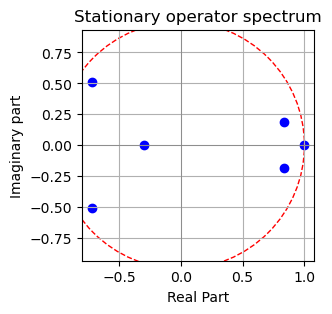

In [3]:
# --!--------------------------------------------------------------------------!
# --! visualize stationary operator eigenvalues

with torch.no_grad():
    utils_plot.plot_eigs(model)

Furthermore, modal amplitude plots below confirm that each pair of complex eigenvalues contributes selectively depending on the frequency content of input time series.

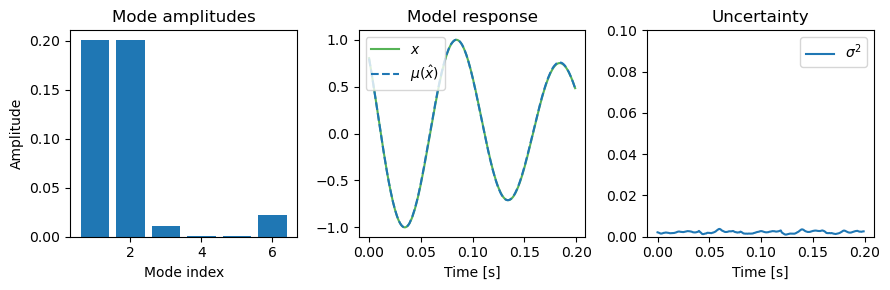

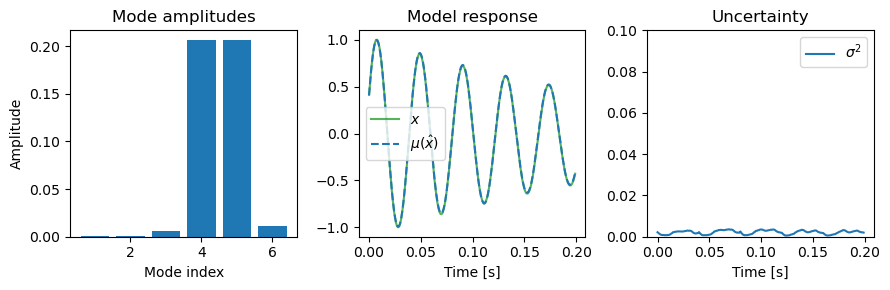

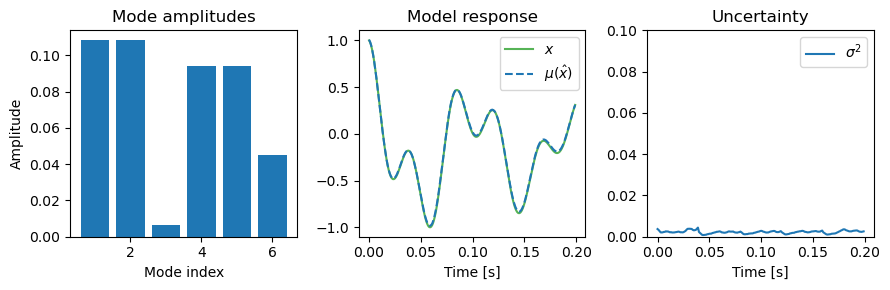

In [4]:
# --!--------------------------------------------------------------------------!
# --! analyze the contribution of stationary operator eigenvalues

datadir            = 'data/train_sim_g'
timeseries_nsample = 200

with torch.no_grad():
    for jtimeseries in range(3):
        utils_plot.plot_modes(model, datadir, timeseries_nsample, jtimeseries)

### Model evaluation

First, we evaluate the trained stationary operator on test data that features a transition. As shown below, the operator fails to capture the transient dynamics: it predicts a persistent superposition of the two sinusoids, overestimating frequency components during the transition. This outcome aligns with known limitations of classical DMD methods, which assume stationary linear evolution and lack mechanisms for adapting to distribution shifts or abrupt changes in system behavior.

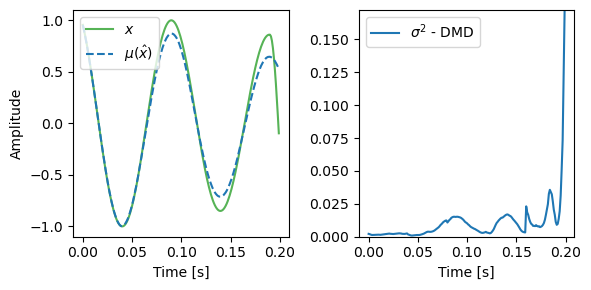

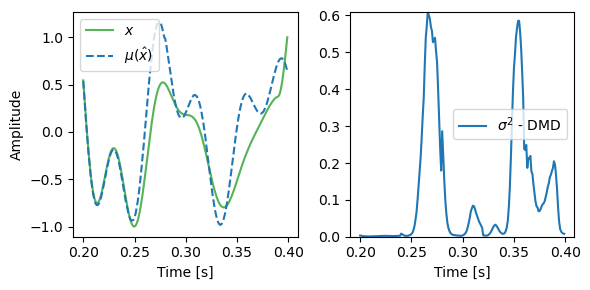

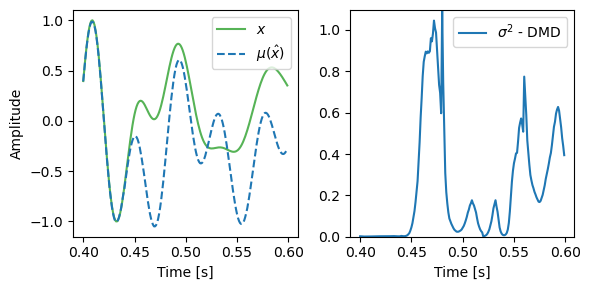

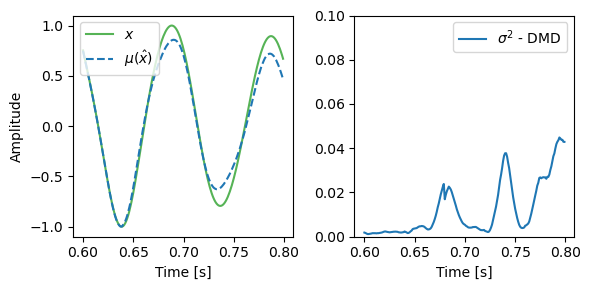

In [5]:
# --!--------------------------------------------------------------------------
# --! evaluate a stationary model

with torch.no_grad():
    test_datadir            = 'data/eval_sim'
    test_timeseries_nsample = 200
    utils_plot.plot_stationary(model, test_datadir, test_timeseries_nsample, datasaved=False)


Next, we evaluate the dynamic operator on the same data. It is clear that the operator, backed by a Transformer, can successfully capture the transient behavior.

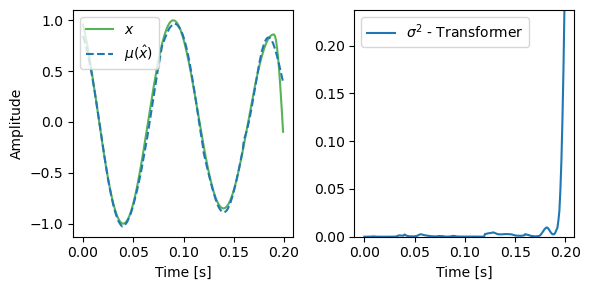

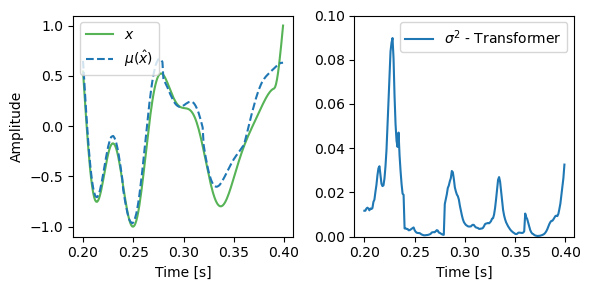

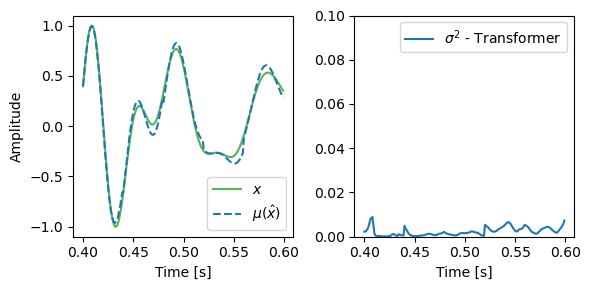

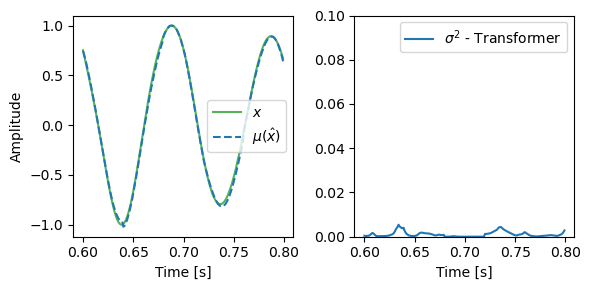

In [6]:
# --!--------------------------------------------------------------------------
# --! evaluate a dynamic model

with torch.no_grad():
    test_datadir            = 'data/eval_sim'
    test_timeseries_nsample = 200
    utils_plot.plot_transient(model, test_datadir, test_timeseries_nsample, datasaved=False)

Finally, we evaluate our alpha blending. The blending acts on a sample-by-sample level by combining the DMD and Transformer predictions with the lowest model uncertainty.

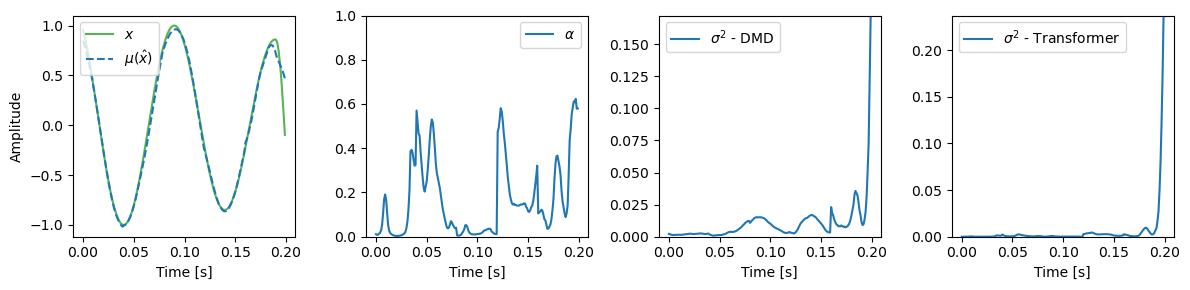

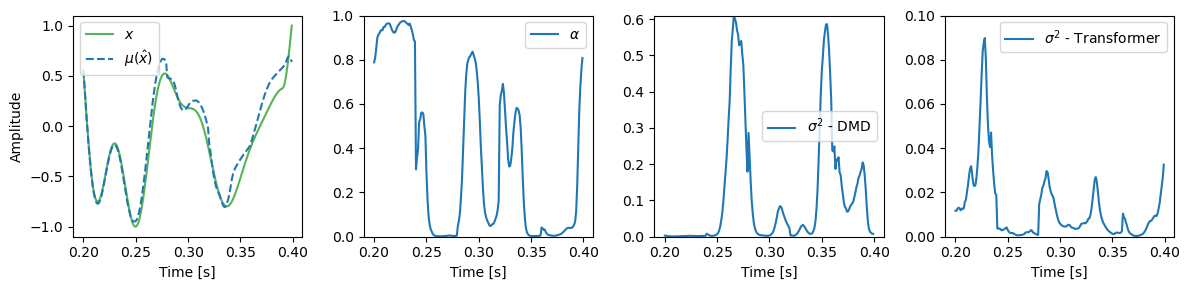

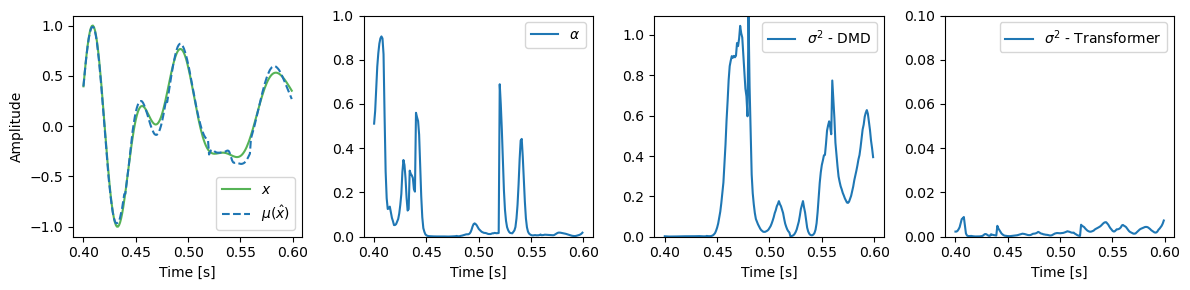

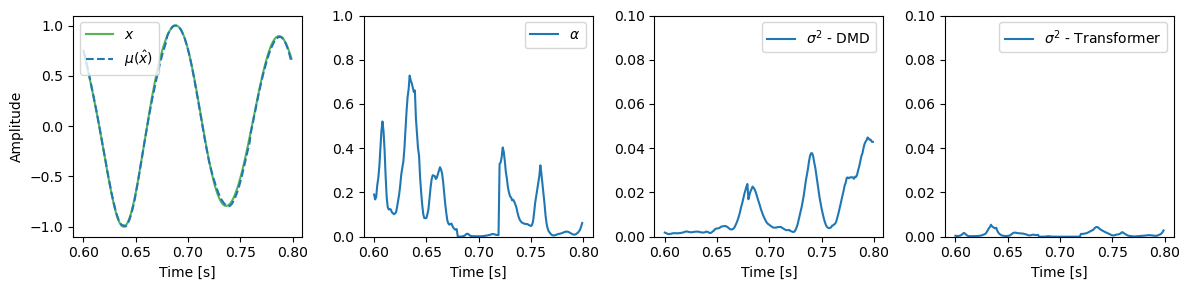

In [7]:
# --!--------------------------------------------------------------------------
# --! evaluate alpha blending

with torch.no_grad():
    test_datadir            = 'data/eval_sim'
    test_timeseries_nsample = 200
    utils_plot.plot_blend(model, test_datadir, test_timeseries_nsample, datasaved=False)